In [16]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda:None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad+= 1.0 * out.grad
            other.grad+=  1.0 * out.grad
        out._backward= _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad+= out.grad * other.data
            other.grad+= out.grad * self.data
        out._backward= _backward
        return out
        
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        
        out._backward = _backward
        return out
        
    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self,other): 
        return self *(other**-1)

    def __neg__(self): # -self
        return self * -1

    def __sub__(self,other):# self + (-other) 
        return self + (-other)
    
    def tanh(self):
        n = self.data
        t = (math.exp(2*n) - 1)/(math.exp(2*n) + 1)
        out = Value(t, (self,),'tanh')
        def _backward():
            self.grad+= (1-t**2)*out.grad
        out._backward= _backward
        
        return out


    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
        # 导数公式：d/dx exp(x) = exp(x)
            self.grad += out.grad* out.data 

        out._backward = _backward
        return out
    
    
    def backward(self):
        
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        
        self.grad= 1.0
        for node in reversed(topo):
            node._backward()


In [ ]:
    # 除法 ：a/b == a*（1/b） == a*（b**-1） == a*(b**k)

In [ ]:
    # def __pow__(self, other):
    #     assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    #     out = Value(self.data**other, (self,), f'**{other}')
    #     def _backward():
    #         self.grad += other * (self.data ** (other - 1)) * out.grad
    #     out._backward = _backward
    #     return out

    # 幂法则 ：a**b  -> b * (a**(b-1))
    # out = pow(self,other)
    # self.grad  = d(over)/d(self) 
    #            = d(over)/d(out) * d(out)/d(self)
    #            = out.gard * other * (self.data ** (other - 1)) 

In [10]:
from graphviz import Digraph

def trace(root):
    # builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label , n.data ,n.grad ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [4]:
# input x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weight w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.881373, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o=n.tanh();o.label='o'

o.backward()

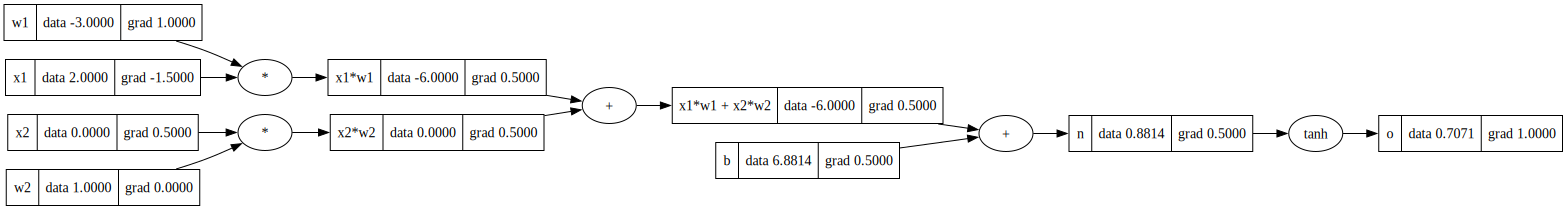

In [5]:
draw_dot(o)

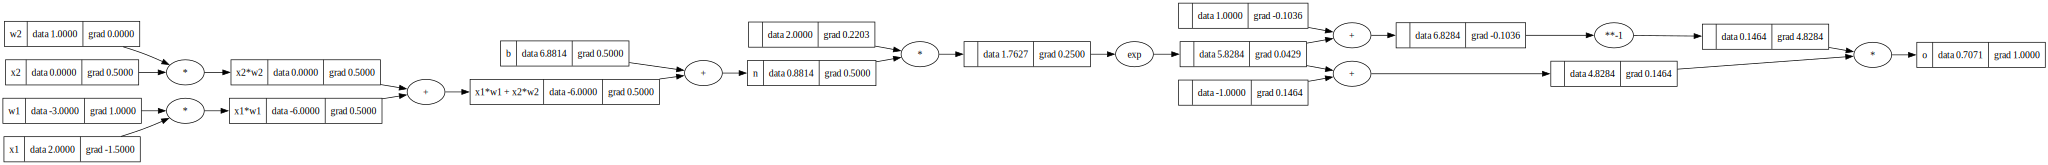

In [61]:
# input x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weight w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias b
b = Value(6.881373, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
#-------

e=(2 * n).exp()
o=(e - 1)/(e + 1)

#-------
o.label='o'
o.backward()
draw_dot(o)

In [6]:
import torch

In [4]:

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('------------------')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
------------------
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [11]:
import random

In [12]:
class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:   
            ps = neuron.parameters()  
            params.extend(ps)
        return params

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
     
    def parameters(self):
        return [p for layers in self.layers for p in layers.parameters()]


In [13]:
n = MLP(3,[4,4,1])

In [14]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [7]:
#loss 损失函数：用单一数值来很衡量神经网络整体性能

In [18]:
for k in range(20):

    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt, yout in zip(ys, ypred)), Value(0.0))
    
    # backward pass
    for p in n.parameters():
        p.grad = 0.0 
    loss.backward()

    # updata
    for p in n.parameters():
        p.data += -0.01 * p.grad

    print(k,loss.data)

0 0.006125297342860168
1 0.006106866754812096
2 0.006088548325204855
3 0.006070341003911954
4 0.006052243754332159
5 0.006034255553164633
6 0.006016375390188974
7 0.005998602268049458
8 0.005980935202043959
9 0.005963373219916852
10 0.005945915361656419
11 0.005928560679295961
12 0.005911308236719256
13 0.005894157109469534
14 0.0058771063845626005
15 0.005860155160303356
16 0.005843302546106117
17 0.005826547662318441
18 0.005809889640048221
19 0.005793327620994462


In [19]:
ypred

[Value(data=0.9639480932913046),
 Value(data=-0.9762918331203264),
 Value(data=-0.9569504225904145),
 Value(data=0.9544122346267813)]

In [20]:
n.parameters()

[Value(data=-0.3019990757200849),
 Value(data=-0.7183074836220159),
 Value(data=1.1646193400380735),
 Value(data=0.5032312469962855),
 Value(data=0.6267934521941687),
 Value(data=0.612379355308102),
 Value(data=0.32800230635024),
 Value(data=-0.40922968463257553),
 Value(data=0.003920466606588399),
 Value(data=0.14642903184154407),
 Value(data=-0.5300461572721891),
 Value(data=0.3789183802658289),
 Value(data=0.11912179713256918),
 Value(data=0.6820696044723373),
 Value(data=-0.8037788508492282),
 Value(data=-0.5824644235412171),
 Value(data=0.6869672156754564),
 Value(data=-0.16251721850612214),
 Value(data=-0.8359139246534516),
 Value(data=0.09901865666299982),
 Value(data=-1.0121444402586772),
 Value(data=0.8269456217068669),
 Value(data=0.3899338388573832),
 Value(data=0.6333293561058276),
 Value(data=-0.26232436940018966),
 Value(data=-0.7972185047366642),
 Value(data=-1.1404036233788646),
 Value(data=0.6965662055743962),
 Value(data=-0.5401848573634424),
 Value(data=0.88371318830